# Sulfur Deposition Analysis in Natural Gas Systems with NeqSim

This notebook demonstrates NeqSim's capabilities for simulating:

1. **Elemental sulfur formation** from H₂S oxidation using Gibbs energy minimization
2. **Sulfur solubility** in sour natural gas at various T/P conditions
3. **Sulfur precipitation** (solid S₈ deposition) and deposition-onset mapping
4. **FeS corrosion** risk assessment in pipelines
5. **Process-level sulfur tracking** across offshore and onshore gas value chains

The underlying thermodynamics use the SRK equation of state with solid-phase fugacity models for S₈ and Newton–Raphson Gibbs free energy minimization for chemical equilibrium.

**Reference notebook:** [Colab – Elemental Sulfur](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/material/elemental_sulfur.ipynb)

## 1. Install and Import NeqSim Libraries

In [1]:
%pip install -e /workspaces/neqsim/devtools/ -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 1 — Start JVM with NeqSim classpath (already compiled)
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_init(recompile=False)

Classpath:
  1. /workspaces/neqsim/target/classes
  2. /workspaces/neqsim/src/main/resources
  3. /workspaces/neqsim/target/neqsim-3.4.0.jar

JVM started: /usr/lib/jvm/msopenjdk-current/lib/server/libjvm.so
Ready — call neqsim_classes(ns) to import classes


In [3]:
# Cell 2 — Import standard NeqSim classes + sulfur-specific ones
import jpype
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

ns = neqsim_classes(ns)  # standard set (SystemSrkEos, Stream, Separator, etc.)

# Add sulfur-specific classes not in the standard set
ns.GibbsReactor = jpype.JClass("neqsim.process.equipment.reactor.GibbsReactor")
ns.SulfurDepositionAnalyser = jpype.JClass("neqsim.process.equipment.reactor.SulfurDepositionAnalyser")

# Local aliases for readability
SystemSrkEos = ns.SystemSrkEos
ThermodynamicOperations = ns.ThermodynamicOperations
Stream = ns.Stream
Separator = ns.Separator
Cooler = ns.Cooler
Heater = ns.Heater
ThrottlingValve = ns.ThrottlingValve
ProcessSystem = ns.ProcessSystem
GibbsReactor = ns.GibbsReactor
SulfurDepositionAnalyser = ns.SulfurDepositionAnalyser

All NeqSim classes imported OK


## 2. Define Gas Composition with H₂S, CO₂, and Trace Sulfur Species

We create a sour natural gas fluid using the SRK equation of state. The composition includes:
- Hydrocarbons: methane (dominant), ethane, propane
- Acid gases: H₂S (5 mol%), CO₂
- Trace: elemental sulfur (S₈) near saturation, SO₂, oxygen (trace from air ingress)
- Water vapour

The SRK EOS with `setMixingRule(2)` (Huron–Vidal) provides reasonable predictions for polar sulfur species.

In [4]:
# Create sour natural gas fluid
# Temperature in Kelvin, Pressure in bara
T_inlet_C = 80.0
P_inlet_bar = 150.0

gas = SystemSrkEos(273.15 + T_inlet_C, P_inlet_bar)

# Add components with mole fractions
gas.addComponent("methane", 0.82)
gas.addComponent("ethane", 0.05)
gas.addComponent("propane", 0.02)
gas.addComponent("CO2", 0.03)
gas.addComponent("H2S", 0.05)          # 5 mol% H2S (sour gas)
gas.addComponent("nitrogen", 0.02)
gas.addComponent("water", 0.005)
gas.addComponent("oxygen", 0.00005)    # Trace O2 from air ingress
gas.addComponent("S8", 1.0e-8)         # Trace S8 (near zero initially)
gas.addComponent("SO2", 0.0)           # Product placeholder

# Set mixing rule (2 = Huron-Vidal for polar sulfur species)
gas.setMixingRule(2)

print("Sour gas fluid created:")
print(f"  Temperature: {T_inlet_C:.0f} °C")
print(f"  Pressure:    {P_inlet_bar:.0f} bara")
print(f"  H2S content: {0.05 * 100:.1f} mol%")
print(f"  Components:  {gas.getNumberOfComponents()}")

Sour gas fluid created:
  Temperature: 80 °C
  Pressure:    150 bara
  H2S content: 5.0 mol%
  Components:  10


## 3. Configure Solid and Multiphase Thermodynamic Model for Sulfur (S₈)

NeqSim models solid sulfur (S₈) using a solid fugacity approach. The solid-fluid equilibrium condition is:

$$f_{\text{S8}}^{\text{solid}} = f_{\text{S8}}^{\text{gas}}$$

where the solid fugacity is calculated from the sublimation pressure correlation and Poynting correction for pressure effects. We enable solid phase checking with `setSolidPhaseCheck("S8")`.

**Key references:**
- Heidemann et al. (1976) – Solid-fluid phase equilibria
- Chrastil (1982) – Solubility of sulfur in supercritical gases
- Roof (1971) – Solubility of sulfur in natural gas

In [5]:
# Enable solid phase check for S8 and run a single TP-solid flash
sys_test = gas.clone()
sys_test.setMultiPhaseCheck(True)
sys_test.setSolidPhaseCheck("S8")

ops = ThermodynamicOperations(sys_test)
ops.TPSolidflash()

n_phases = sys_test.getNumberOfPhases()
has_solid = sys_test.hasPhaseType("solid")

print(f"Flash at {T_inlet_C:.0f} C, {P_inlet_bar:.0f} bar:")
print(f"  Number of phases: {n_phases}")
print(f"  Solid sulfur present: {has_solid}")

# Show phase fractions
for phase_idx in range(n_phases):
    phase = sys_test.getPhase(phase_idx)
    print(f"  Phase {phase_idx} ({phase.getPhaseTypeName()}): beta = {sys_test.getBeta(phase_idx):.6e}")

Flash at 80 C, 150 bar:
  Number of phases: 2
  Solid sulfur present: False
  Phase 0 (gas): beta = 9.997696e-01
  Phase 1 (aqueous): beta = 2.303832e-04


## 4. Calculate Sulfur Solubility in Natural Gas vs Temperature and Pressure

Sulfur solubility in natural gas increases with temperature and pressure. We sweep across a T-P grid and record the S₈ mole fraction in the gas phase after TP-solid flash. The solubility relationship follows approximately:

$$\ln(y_{S8}) = A + \frac{B}{T} + C \ln(P)$$

where $y_{S8}$ is the S₈ mole fraction in the gas, $T$ is temperature (K), and $P$ is pressure (bara).

In [6]:
# Sweep T and P to map S8 solubility
temperatures_C = np.arange(10, 160, 10)       # 10-150 C
pressures_bar = [50, 100, 150, 200, 300]       # bara

S8_MOLAR_MASS = 256.48e-3  # kg/mol
R = 8.314                  # J/(mol·K)
MOL_FRAC_TO_MG_SM3 = S8_MOLAR_MASS * 1e6 * (101325.0 / (R * 288.15))

solubility_data = []

for P in pressures_bar:
    for T_C in temperatures_C:
        try:
            sys = gas.clone()
            sys.setTemperature(float(273.15 + T_C))
            sys.setPressure(float(P))
            sys.setMultiPhaseCheck(True)
            sys.setSolidPhaseCheck("S8")

            ops = ThermodynamicOperations(sys)
            ops.TPSolidflash()

            # Get S8 mole fraction in gas phase
            gas_phase_num = sys.getPhaseNumberOfPhase("gas")
            if gas_phase_num >= 0:
                s8_gas = float(sys.getPhase(gas_phase_num).getComponent("S8").getx())
            else:
                s8_gas = float(sys.getPhase(0).getComponent("S8").getx())

            has_solid = bool(sys.hasPhaseType("solid"))

            solubility_data.append({
                'T_C': float(T_C), 'P_bar': float(P),
                'S8_molFrac': s8_gas,
                'S8_mgSm3': s8_gas * MOL_FRAC_TO_MG_SM3,
                'solidPresent': has_solid
            })
        except Exception as e:
            pass

df_sol = pd.DataFrame(solubility_data)
print(f"Calculated {len(df_sol)} solubility points")
df_sol.head(10)

Calculated 75 solubility points


,T_C,P_bar,S8_molFrac,S8_mgSm3,solidPresent
0,10.0,50.0,2.684772e-10,0.002912,True
1,20.0,50.0,8.131176e-10,0.008821,True
2,30.0,50.0,2.321287e-09,0.025181,True
3,40.0,50.0,6.262021e-09,0.067929,True
4,50.0,50.0,8.411343e-09,0.091245,False
5,60.0,50.0,9.285825e-09,0.100731,False
6,70.0,50.0,1.004975e-08,0.109018,False
7,80.0,50.0,1.004975e-08,0.109018,False
8,90.0,50.0,1.004975e-08,0.109018,False
9,100.0,50.0,1.004975e-08,0.109018,False


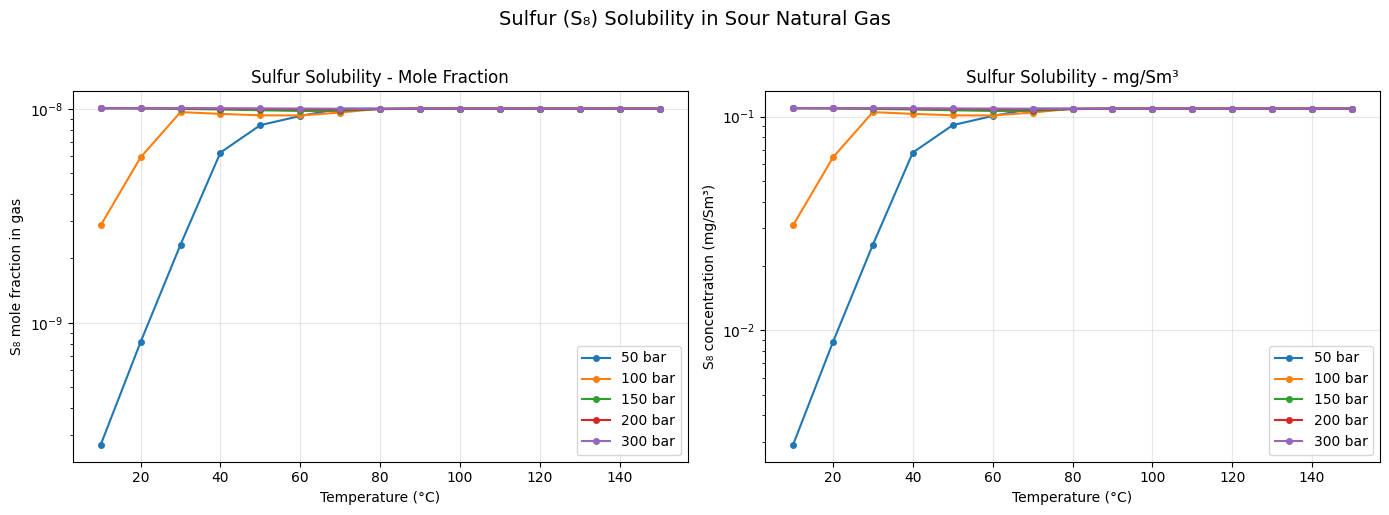

In [7]:
# Plot S8 solubility vs temperature at different pressures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for P in pressures_bar:
    subset = df_sol[df_sol['P_bar'] == P]
    ax1.semilogy(subset['T_C'], subset['S8_molFrac'], 'o-', label=f'{P} bar', markersize=4)
    ax2.semilogy(subset['T_C'], subset['S8_mgSm3'], 'o-', label=f'{P} bar', markersize=4)

ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('S₈ mole fraction in gas')
ax1.set_title('Sulfur Solubility - Mole Fraction')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('S₈ concentration (mg/Sm³)')
ax2.set_title('Sulfur Solubility - mg/Sm³')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Sulfur (S₈) Solubility in Sour Natural Gas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Map Sulfur Saturation Envelope – Identify Precipitation Conditions

The **sulfur dew point curve** is the locus of (T, P) conditions where solid S₈ first appears. Operating below this curve means sulfur precipitates as a solid – causing plugging in pipelines, heat exchangers, and valves.

We scan the T-P space and mark where the solid phase appears.

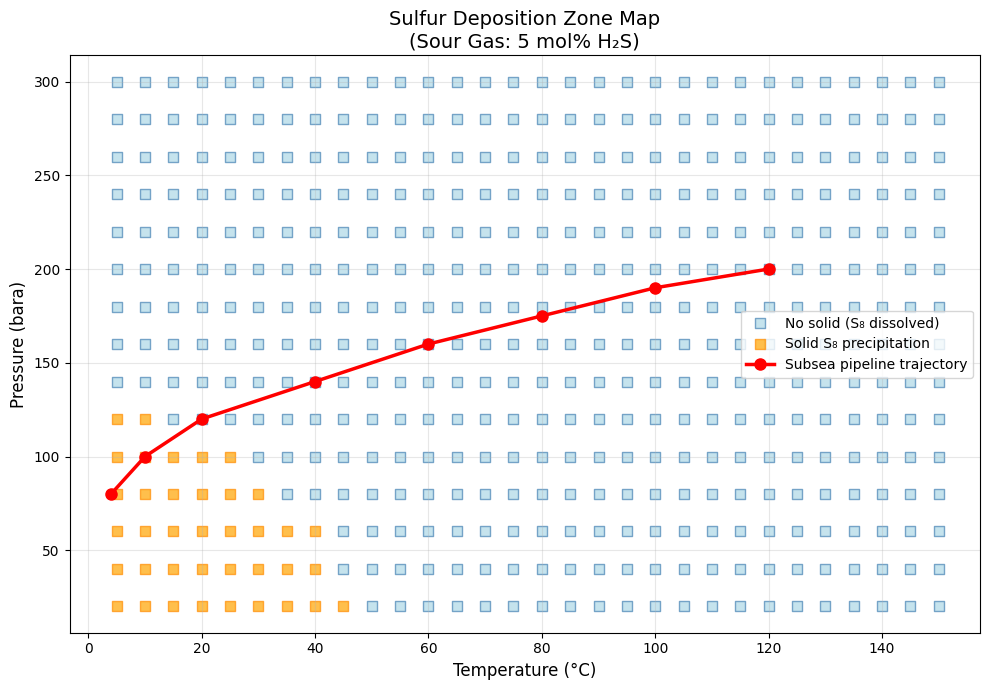

In [8]:
# Map the sulfur deposition zone on P-T diagram
T_range = np.arange(5, 155, 5)
P_range = np.arange(20, 320, 20)

deposition_map = []
for P in P_range:
    for T_C in T_range:
        try:
            sys = gas.clone()
            sys.setTemperature(float(273.15 + T_C))
            sys.setPressure(float(P))
            sys.setMultiPhaseCheck(True)
            sys.setSolidPhaseCheck("S8")
            ops = ThermodynamicOperations(sys)
            ops.TPSolidflash()
            has_solid = bool(sys.hasPhaseType("solid"))
            deposition_map.append({
                'T_C': float(T_C), 'P_bar': float(P), 'solidPresent': has_solid
            })
        except:
            pass

df_map = pd.DataFrame(deposition_map)

# Plot the deposition zone
fig, ax = plt.subplots(figsize=(10, 7))

solid_pts = df_map[df_map['solidPresent'] == True]
gas_pts = df_map[df_map['solidPresent'] == False]

ax.scatter(gas_pts['T_C'], gas_pts['P_bar'], c='lightblue', marker='s', s=50,
           label='No solid (S₈ dissolved)', alpha=0.7, edgecolors='steelblue')
ax.scatter(solid_pts['T_C'], solid_pts['P_bar'], c='orange', marker='s', s=50,
           label='Solid S₈ precipitation', alpha=0.7, edgecolors='darkorange')

# Show a typical offshore pipeline trajectory
pipeline_T = [120, 100, 80, 60, 40, 20, 10, 4]
pipeline_P = [200, 190, 175, 160, 140, 120, 100, 80]
ax.plot(pipeline_T, pipeline_P, 'r-o', linewidth=2.5, markersize=8,
        label='Subsea pipeline trajectory', zorder=5)

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Pressure (bara)', fontsize=12)
ax.set_title('Sulfur Deposition Zone Map\n(Sour Gas: 5 mol% H₂S)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Set Up Gibbs Energy Minimization Reactor for Claus-Type Reactions

NeqSim's `GibbsReactor` finds the chemical equilibrium composition by minimizing the total Gibbs free energy:

$$G = \sum_i n_i \left( G_i^0 + RT \ln \frac{f_i}{f_i^0} \right)$$

subject to elemental balance constraints (conservation of C, H, O, S, N atoms). The primary sulfur-forming reaction is the Claus reaction:

$$2\text{H}_2\text{S} + \text{O}_2 \rightarrow 2\text{H}_2\text{O} + \frac{1}{4}\text{S}_8$$

The solver uses Newton–Raphson with Lagrange multipliers for element balances.

In [9]:
# Set up a simple H2S + O2 reaction system for Gibbs minimization
reaction_fluid = SystemSrkEos(273.15 + 400.0, 1.5)  # 400 C, 1.5 bara (Claus conditions)

# Feed: 2 mol H2S + 1 mol O2 (stoichiometric for Claus)
reaction_fluid.addComponent("H2S", 2.0)
reaction_fluid.addComponent("oxygen", 1.0)
reaction_fluid.addComponent("water", 0.0)    # Product
reaction_fluid.addComponent("S8", 0.0)       # Product
reaction_fluid.addComponent("SO2", 0.0)      # Side product
reaction_fluid.setMixingRule(2)

# Create stream and Gibbs reactor
feed_stream = Stream("H2S_O2_feed", reaction_fluid)
feed_stream.run()

reactor = GibbsReactor("Claus_reactor", feed_stream)
reactor.setEnergyMode("isothermal")
reactor.setMaxIterations(5000)
reactor.setConvergenceTolerance(1e-4)
reactor.setDampingComposition(0.01)
reactor.run()

# Get equilibrium composition
out_sys = reactor.getOutletStream().getThermoSystem()
print("Gibbs reactor equilibrium at 400°C, 1.5 bara:")
print(f"  Converged: {reactor.hasConverged()}")
print(f"  Iterations: {reactor.getActualIterations()}")
print()
for i in range(out_sys.getNumberOfComponents()):
    name = str(out_sys.getComponent(i).getComponentName())
    z = float(out_sys.getComponent(i).getz())
    print(f"  {name:20s}: z = {z:.6e} ({z*100:.4f} mol%)")

Gibbs reactor equilibrium at 400°C, 1.5 bara:
  Converged: True
  Iterations: 996

  H2S                 : z = 1.159958e-01 (11.5996 mol%)
  oxygen              : z = 4.283302e-07 (0.0000 mol%)
  water               : z = 7.406647e-01 (74.0665 mol%)
  S8                  : z = 8.533223e-02 (8.5332 mol%)
  SO2                 : z = 5.800685e-02 (5.8007 mol%)


## 7. Simulate Partial Oxidation of H₂S to Elemental Sulfur – Temperature Sweep

We run the Gibbs reactor across a wide temperature range (200–1200 °C) at 1.5 bara to show how
the equilibrium product distribution changes:
- At low temperatures: S₈ is the stable sulfur allotrope
- Above ~600 °C: S₂ becomes thermodynamically favoured over S₈
- H₂O is a major product of H₂S oxidation
- SO₂ formation competes when excess O₂ is present

In [10]:
# Temperature sweep: Gibbs equilibrium products vs temperature
# Feed: 2 mol H2S + 1 mol O2 at 1.5 bara
temps_reactor = np.arange(200, 1250, 50)  # 200-1200 C
species_to_track = ["H2S", "S8", "SO2", "water", "oxygen"]

equil_data = []

for T_C in temps_reactor:
    try:
        rxn_fluid = SystemSrkEos(float(273.15 + T_C), 1.5)
        rxn_fluid.addComponent("H2S", 2.0)
        rxn_fluid.addComponent("oxygen", 1.0)
        rxn_fluid.addComponent("water", 0.0)
        rxn_fluid.addComponent("S8", 0.0)
        rxn_fluid.addComponent("SO2", 0.0)
        rxn_fluid.setMixingRule(2)

        fs = Stream("feed", rxn_fluid)
        fs.run()

        rxr = GibbsReactor("rxr", fs)
        rxr.setEnergyMode("isothermal")
        rxr.setMaxIterations(5000)
        rxr.setConvergenceTolerance(1e-4)
        rxr.setDampingComposition(0.01)
        rxr.run()

        out = rxr.getOutletStream().getThermoSystem()
        row = {"T_C": float(T_C), "converged": bool(rxr.hasConverged())}
        for sp in species_to_track:
            try:
                row[sp] = float(out.getComponent(sp).getz())
            except:
                row[sp] = 0.0
        equil_data.append(row)
    except Exception as e:
        pass

df_equil = pd.DataFrame(equil_data)
print(f"Computed {len(df_equil)} equilibrium points")
df_equil.head()

Computed 21 equilibrium points


,T_C,converged,H2S,S8,SO2,water,oxygen
0,200.0,True,0.009970,0.108891,0.005006,0.876132,4.430514e-07
1,250.0,True,0.022956,0.106006,0.011495,0.859543,4.412493e-07
2,300.0,True,0.044660,0.101183,0.022344,0.831812,4.382360e-07
3,350.0,True,0.076000,0.094220,0.038011,0.791769,4.338844e-07
4,400.0,True,0.115996,0.085332,0.058007,0.740665,4.283302e-07


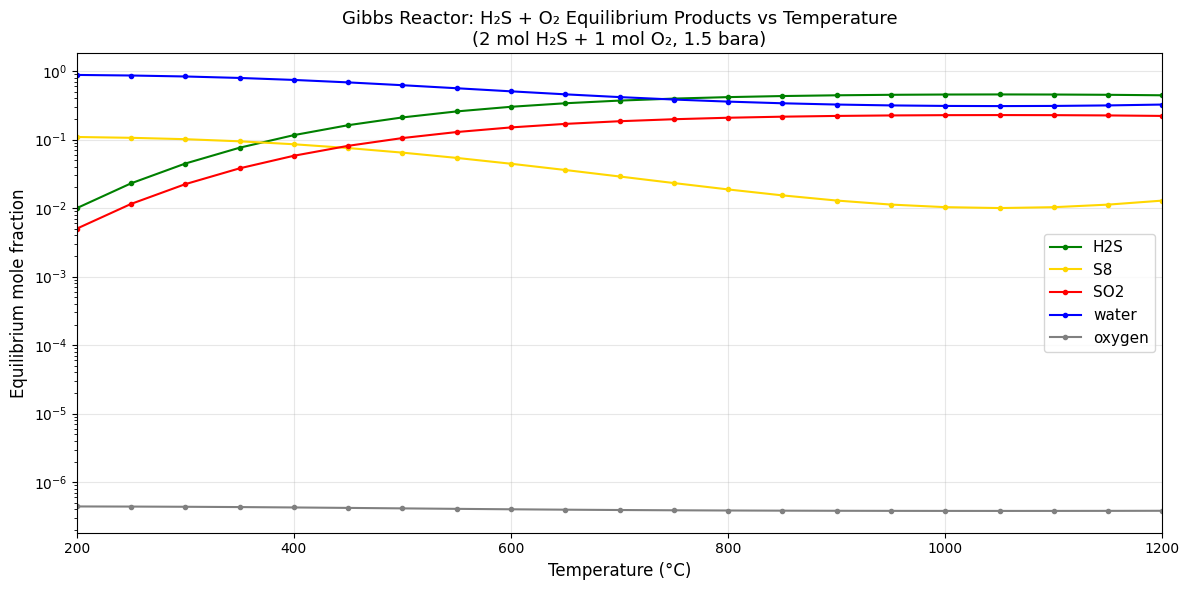

In [11]:
# Plot equilibrium product distribution vs temperature
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'H2S': 'green', 'S8': 'gold', 'SO2': 'red', 'water': 'blue', 'oxygen': 'gray'}
for sp in species_to_track:
    if sp in df_equil.columns:
        ax.semilogy(df_equil['T_C'], df_equil[sp].clip(lower=1e-20), '-o',
                     label=sp, color=colors.get(sp, None), markersize=3)

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Equilibrium mole fraction', fontsize=12)
ax.set_title('Gibbs Reactor: H₂S + O₂ Equilibrium Products vs Temperature\n(2 mol H₂S + 1 mol O₂, 1.5 bara)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(200, 1200)
plt.tight_layout()
plt.show()

## 8. Simulate Side Reactions: SO₂ Formation and O₂/H₂S Ratio Sensitivity

When excess O₂ is present, H₂S is fully oxidised to SO₂ rather than elemental sulfur:

$$\text{H}_2\text{S} + \frac{3}{2}\text{O}_2 \rightarrow \text{SO}_2 + \text{H}_2\text{O}$$

The ratio of O₂ to H₂S in the feed controls whether sulfur or SO₂ dominates. We sweep the O₂/H₂S molar ratio from 0.1 to 2.0 at 350 °C.

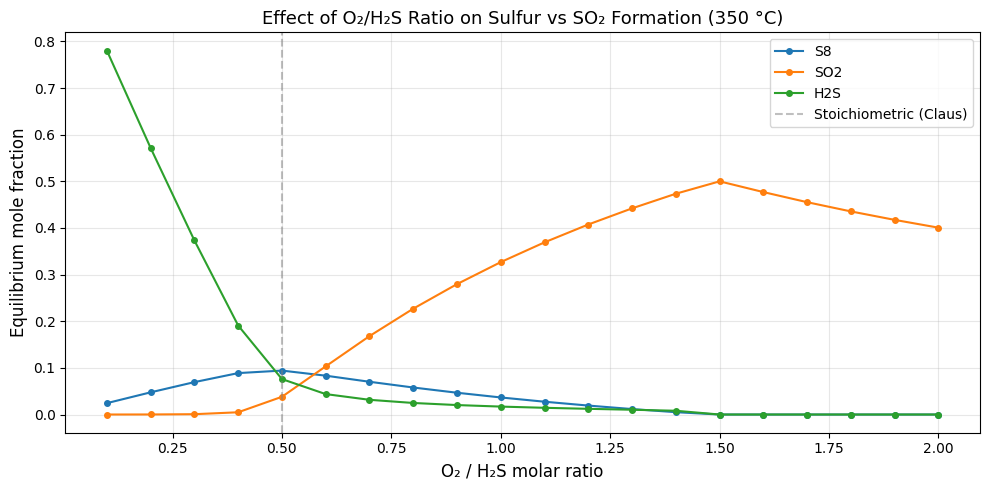

In [12]:
# Sweep O2/H2S ratio at 350 C
o2_h2s_ratios = np.arange(0.1, 2.05, 0.1)
ratio_data = []

for ratio in o2_h2s_ratios:
    try:
        rxn = SystemSrkEos(273.15 + 350.0, 1.5)
        rxn.addComponent("H2S", 2.0)
        rxn.addComponent("oxygen", float(2.0 * ratio))
        rxn.addComponent("water", 0.0)
        rxn.addComponent("S8", 0.0)
        rxn.addComponent("SO2", 0.0)
        rxn.setMixingRule(2)

        fs = Stream("feed", rxn)
        fs.run()
        rxr = GibbsReactor("rxr", fs)
        rxr.setEnergyMode("isothermal")
        rxr.setMaxIterations(5000)
        rxr.setConvergenceTolerance(1e-4)
        rxr.setDampingComposition(0.01)
        rxr.run()

        out = rxr.getOutletStream().getThermoSystem()
        row = {"O2_H2S_ratio": float(ratio)}
        for sp in ["H2S", "S8", "SO2", "water", "oxygen"]:
            try:
                row[sp] = float(out.getComponent(sp).getz())
            except:
                row[sp] = 0.0
        ratio_data.append(row)
    except:
        pass

df_ratio = pd.DataFrame(ratio_data)

fig, ax = plt.subplots(figsize=(10, 5))
for sp in ["S8", "SO2", "H2S"]:
    ax.plot(df_ratio['O2_H2S_ratio'], df_ratio[sp], '-o', label=sp, markersize=4)

ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Stoichiometric (Claus)')
ax.set_xlabel('O₂ / H₂S molar ratio', fontsize=12)
ax.set_ylabel('Equilibrium mole fraction', fontsize=12)
ax.set_title('Effect of O₂/H₂S Ratio on Sulfur vs SO₂ Formation (350 °C)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. FeS Corrosion Assessment – Using the SulfurDepositionAnalyser

The `SulfurDepositionAnalyser` unit operation combines chemical equilibrium (Gibbs reactor), solid S₈ flash, temperature sweep, and corrosion risk assessment in a single `run()` call. It evaluates:

- **FeS formation risk** based on H₂S partial pressure and water presence
- **NACE MR0175 sour severity** classification
- **SO₂/H₂SO₄ corrosion risk**
- **Sulfur deposition onset temperature** from temperature sweep

The iron sulfide corrosion reaction: $\text{Fe} + \text{H}_2\text{S} \rightarrow \text{FeS} + \text{H}_2$

FeS formation is thermodynamically favourable at all temperatures ($\Delta G_f^0 = -100.4$ kJ/mol) but accelerates above 60 °C.

In [13]:
# Run the complete SulfurDepositionAnalyser on the sour gas
feed = Stream("sour_gas_feed", gas)
feed.setFlowRate(100000.0, "kg/hr")
feed.run()

analyser = SulfurDepositionAnalyser("Sulfur_Analyser", feed)
analyser.setTemperatureSweepRange(0.0, 200.0, 5.0)  # 0-200 C in 5 C steps
analyser.run()

# Print summary
print("="*60)
print("SULFUR DEPOSITION ANALYSER RESULTS")
print("="*60)
print(f"S8 solubility in gas: {analyser.getSulfurSolubilityInGas():.4e} mol frac")
print(f"S8 solubility:        {analyser.getSulfurSolubilityMgSm3():.4f} mg/Sm³")
print(f"Solid sulfur present: {analyser.isSolidSulfurPresent()}")
print(f"Deposition onset T:   {analyser.getSulfurDepositionOnsetTemperature():.1f} °C")
print(f"Corrosion risk:       {analyser.hasCorrosionRisk()}")

# Show corrosion details
corr = dict(analyser.getCorrosionAssessment())
print(f"\nNACE sour severity:   {corr.get('sourSeverityNACE', 'N/A')}")
print(f"H2S partial pressure: {corr.get('H2S_partialPressure_kPa', 0):.1f} kPa")
print(f"FeS formation risk:   {corr.get('FeS_formationRisk', 'N/A')}")
print(f"FeS category:         {corr.get('FeS_corrosionCategory', 'N/A')}")
print(f"SO2 corrosion risk:   {corr.get('SO2_corrosionRisk', 'N/A')}")

SULFUR DEPOSITION ANALYSER RESULTS
S8 solubility in gas: 1.0004e-08 mol frac
S8 solubility:        0.1085 mg/Sm³
Solid sulfur present: False
Deposition onset T:   nan °C
Corrosion risk:       True

NACE sour severity:   Severe sour (> 10 kPa H2S)
H2S partial pressure: 753.7 kPa
FeS formation risk:   True
FeS category:         Very high FeS risk (> 1000 ppm H2S)
SO2 corrosion risk:   False


## 9A. Root Cause Analysis — Reaction Kinetics

A critical question in sulfur deposition root cause analysis is: **where does the elemental sulfur come from?**

There are two fundamentally different mechanisms:

1. **Thermodynamic precipitation** (dominant at T < 150 °C): S₈ was dissolved in the reservoir gas and precipitates when solubility decreases upon cooling/depressurisation. The H₂S oxidation reaction is kinetically frozen — the half-life at pipeline temperatures is measured in **years to millennia**.

2. **Chemical reaction** (dominant at T > 300 °C): H₂S + O₂ → S₈ + H₂O occurs at measurable rates. This is relevant in Claus units, wellbore hot zones, and thermal reactors.

The `SulfurDepositionAnalyser` now includes **Arrhenius kinetics** to distinguish between these mechanisms:

$$k = A \exp\left(-\frac{E_a}{RT}\right)$$

- **Uncatalysed H₂S thermal oxidation**: $E_a$ = 160 kJ/mol, $A$ = 10¹⁰ s⁻¹ (Monnery et al., 1993; Karan et al., 1999)
- **FeS corrosion rate**: Smith–de Waard sour corrosion model: $\ln(\text{CR}) = 7.96 - 2320/T + 0.67\ln(p_{\text{H₂S}})$
- **FeS scale morphology**: Mackinawite (< 60 °C) → Mixed (60–120 °C) → Pyrrhotite (> 120 °C)

In [14]:
# Retrieve kinetic analysis from the analyser
kinetics = dict(analyser.getKineticAnalysis())

print("=" * 70)
print("ROOT CAUSE ANALYSIS — REACTION KINETICS")
print("=" * 70)

# H2S Oxidation kinetics
print("\n--- H₂S Thermal Oxidation (2 H₂S + O₂ → S₈ + 2 H₂O) ---")
print(f"  Activation energy:     {kinetics.get('H2S_oxidation_Ea_Jmol', 0)/1000:.0f} kJ/mol")
print(f"  Rate constant k:       {kinetics.get('H2S_oxidation_rateConst_1s', 0):.4e} 1/s")
half_life_s = kinetics.get('H2S_oxidation_halfLife_s', 0)
half_life_days = kinetics.get('H2S_oxidation_halfLife_days', 0)
if half_life_days > 365:
    print(f"  Half-life:             {half_life_days/365:.1e} years")
elif half_life_days > 1:
    print(f"  Half-life:             {half_life_days:.1f} days")
else:
    print(f"  Half-life:             {half_life_s:.1f} seconds")
print(f"  Kinetically feasible:  {kinetics.get('H2S_oxidation_kineticallyFeasible', False)}")

# Oxidation note (the key insight)
print(f"\n  >>> {kinetics.get('H2S_oxidation_note', '')}")

# FeS Corrosion kinetics
print("\n--- FeS Corrosion (Fe + H₂S → FeS + H₂) ---")
print(f"  H₂S partial pressure:  {kinetics.get('H2S_partialPressure_bar', 0):.2f} bar")
print(f"  Corrosion rate:        {kinetics.get('FeS_corrosionRate_mmYear', 0):.2f} mm/year")
print(f"  FeS scale type:        {kinetics.get('FeS_scaleMorphology', 'N/A')}")
print(f"  Scale protectiveness:  {kinetics.get('FeS_scaleProtectiveness', 'N/A')}")
if 'yearsToWallPenetration' in kinetics:
    print(f"  Years to wall failure: {kinetics.get('yearsToWallPenetration', 0):.1f} years")

# Root cause classification
print("\n--- ROOT CAUSE CLASSIFICATION ---")
root_causes = kinetics.get('rootCauseClassification', [])
if hasattr(root_causes, '__iter__') and not isinstance(root_causes, str):
    for rc in root_causes:
        print(f"  • {rc}")
else:
    print(f"  • {root_causes}")

ROOT CAUSE ANALYSIS — REACTION KINETICS

--- H₂S Thermal Oxidation (2 H₂S + O₂ → S₈ + 2 H₂O) ---
  Activation energy:     160 kJ/mol
  Rate constant k:       2.1550e-14 1/s
  Half-life:             1.0e+06 years
  Kinetically feasible:  False

  >>> At 80 C, H2S thermal oxidation is kinetically negligible (half-life >> years). Sulfur in the gas phase originates from the reservoir, NOT from in-situ pipeline reactions. This means S8 deposition is a THERMODYNAMIC precipitation problem (solubility decrease with cooling) rather than a chemical reaction problem.

--- FeS Corrosion (Fe + H₂S → FeS + H₂) ---
  H₂S partial pressure:  7.54 bar
  Corrosion rate:        15.55 mm/year
  FeS scale type:        Mixed mackinawite/pyrite (FeS/FeS2)
  Scale protectiveness:  Partially protective. Scale integrity depends on flow velocity and pH. Localised pitting possible.
  Years to wall failure: 0.8 years

--- ROOT CAUSE CLASSIFICATION ---
  • PRIMARY: Thermodynamic precipitation - S8 dissolved from res

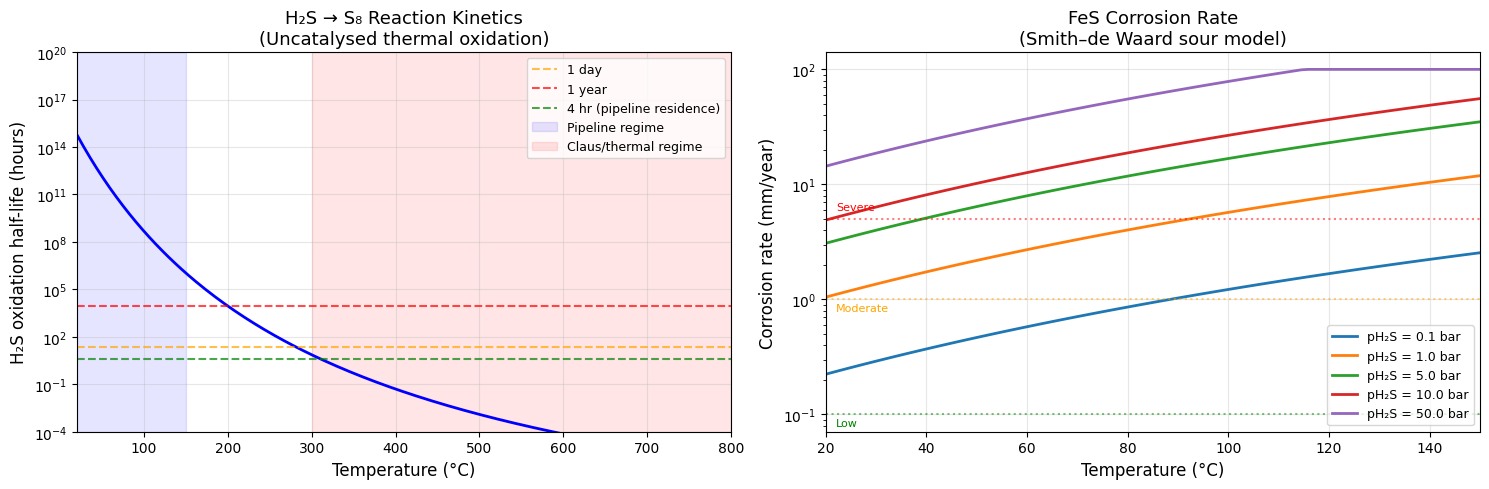

In [15]:
# Plot: H2S oxidation half-life vs temperature — shows kinetic regime boundaries
import numpy as np

R_gas = 8.314
Ea = 160000.0  # J/mol
A = 1.0e10     # 1/s
temp_range_C = np.linspace(20, 800, 200)
temp_range_K = temp_range_C + 273.15

k_values = A * np.exp(-Ea / (R_gas * temp_range_K))
half_lives_s = np.log(2) / np.maximum(k_values, 1e-50)
half_lives_hr = half_lives_s / 3600.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left: Half-life vs temperature
ax1.semilogy(temp_range_C, half_lives_hr, 'b-', linewidth=2)
ax1.axhline(y=24, color='orange', linestyle='--', alpha=0.7, label='1 day')
ax1.axhline(y=24*365, color='red', linestyle='--', alpha=0.7, label='1 year')
ax1.axhline(y=4, color='green', linestyle='--', alpha=0.7, label='4 hr (pipeline residence)')
ax1.axvspan(20, 150, alpha=0.1, color='blue', label='Pipeline regime')
ax1.axvspan(300, 800, alpha=0.1, color='red', label='Claus/thermal regime')
ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_ylabel('H₂S oxidation half-life (hours)', fontsize=12)
ax1.set_title('H₂S → S₈ Reaction Kinetics\n(Uncatalysed thermal oxidation)', fontsize=13)
ax1.legend(fontsize=9, loc='upper right')
ax1.set_xlim(20, 800)
ax1.set_ylim(1e-4, 1e20)
ax1.grid(True, alpha=0.3)

# Right: FeS corrosion rate vs temperature at different H2S partial pressures
ph2s_values = [0.1, 1.0, 5.0, 10.0, 50.0]  # bar
temp_corr_C = np.linspace(20, 150, 100)
temp_corr_K = temp_corr_C + 273.15

for ph2s in ph2s_values:
    cr = np.exp(7.96 - 2320.0/temp_corr_K + 0.67*np.log(ph2s))
    cr = np.minimum(cr, 100.0)
    ax2.semilogy(temp_corr_C, cr, '-', linewidth=2, label=f'pH₂S = {ph2s} bar')

ax2.axhline(y=0.1, color='green', linestyle=':', alpha=0.5)
ax2.axhline(y=1.0, color='orange', linestyle=':', alpha=0.5)
ax2.axhline(y=5.0, color='red', linestyle=':', alpha=0.5)
ax2.text(22, 0.08, 'Low', fontsize=8, color='green')
ax2.text(22, 0.8, 'Moderate', fontsize=8, color='orange')
ax2.text(22, 6.0, 'Severe', fontsize=8, color='red')
ax2.set_xlabel('Temperature (°C)', fontsize=12)
ax2.set_ylabel('Corrosion rate (mm/year)', fontsize=12)
ax2.set_title('FeS Corrosion Rate\n(Smith–de Waard sour model)', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(20, 150)

plt.tight_layout()
plt.show()

## 9B. Supersaturation & Nucleation Analysis

Sulfur deposition is not just about whether the gas is supersaturated — it depends on **how much** supersaturation exists. The supersaturation ratio $\sigma$ determines the deposition regime:

$$\sigma = \frac{y_{\text{S8,actual}}}{y_{\text{S8,saturation}}}$$

| Zone | $\sigma$ | Behaviour |
|------|----------|-----------|
| Undersaturated | $\sigma < 1$ | S₈ remains dissolved. No risk. |
| Metastable | $1 < \sigma < 1.5$ | Heterogeneous nucleation on rough surfaces, FeS scale, or existing S₈ particles. Deposition on pipe walls. |
| Labile | $\sigma > 1.5$ | Spontaneous homogeneous nucleation. Sulfur fog/mist forms. Rapid massive deposition. |

The classical nucleation theory gives the critical nucleus radius and nucleation rate:

$$J = A \exp\left(-\frac{16\pi \gamma^3 v^2}{3 k_B^3 T^3 (\ln \sigma)^2}\right)$$

where $\gamma$ ≈ 0.030 J/m² is the S₈ solid interfacial energy (Mersmann, 2001; Mullin, 2001).

In [16]:
# Retrieve supersaturation analysis
supersat = dict(analyser.getSupersaturationAnalysis())

print("=" * 70)
print("SUPERSATURATION & NUCLEATION ANALYSIS")
print("=" * 70)

print(f"\n  S₈ actual (feed):      {supersat.get('S8_actual_molFrac', 0):.4e} mol frac")
print(f"  S₈ saturation limit:   {supersat.get('S8_saturation_molFrac', 0):.4e} mol frac")
print(f"  Supersaturation ratio: {supersat.get('supersaturationRatio', 0):.4f}")
print(f"  Zone:                  {supersat.get('supersaturationZone', 'N/A')}")
print(f"  Nucleation risk:       {supersat.get('nucleationRisk', 'N/A')}")

if 'criticalNucleusRadius_nm' in supersat:
    print(f"\n  Critical nucleus radius: {supersat.get('criticalNucleusRadius_nm', 0):.2f} nm")
    print(f"  Nucleation barrier:      {supersat.get('nucleationBarrier_kBT', 0):.1f} kBT")
    nuc_rate = supersat.get('nucleationRate_perM3s', 0)
    print(f"  Nucleation rate:         {nuc_rate:.2e} nuclei/(m³·s)")

if 'inductionTime_hours' in supersat:
    ind_hrs = supersat.get('inductionTime_hours', 0)
    if ind_hrs > 24:
        print(f"  Induction time:          {ind_hrs/24:.1f} days")
    else:
        print(f"  Induction time:          {ind_hrs:.2f} hours")

# High-risk locations
locations = supersat.get('highRiskDepositionLocations', [])
if hasattr(locations, '__iter__') and not isinstance(locations, str) and len(list(locations)) > 0:
    print("\n  HIGH-RISK DEPOSITION LOCATIONS:")
    for loc in locations:
        print(f"    • {loc}")

SUPERSATURATION & NUCLEATION ANALYSIS

  S₈ actual (feed):      1.0050e-08 mol frac
  S₈ saturation limit:   1.0050e-08 mol frac
  Supersaturation ratio: 1.0000
  Zone:                  Metastable (slightly supersaturated)
  Nucleation risk:       Low - heterogeneous nucleation possible on rough surfaces, FeS scale, or existing S8 particles


## 9C. Gas vs Liquid S₈ Solubility — The "Sulfur Sponge" Effect

**Key physical fact**: Elemental sulfur (S₈) is approximately **100–1000× more soluble in liquid hydrocarbons** than in the gas phase (Roof, 1971; Roberts, 1997; Chrastil, 1982). This has profound implications for process design:

### Why S₈ dissolves better in liquid hydrocarbons

S₈ is a **nonpolar, high-molecular-weight molecule** (MW = 256 g/mol) that interacts strongly with liquid hydrocarbons via London dispersion forces. In the gas phase, the low molecular density limits these interactions, so S₈ "prefers" the dense liquid phase.

### Implications for operations

| Scenario | What happens | Risk |
|----------|-------------|------|
| **Gas cooling across HC dew point** | Condensing liquid absorbs S₈ from gas → "sulfur sponge" effect | Temporary **reduction** in gas-phase deposition risk |
| **Liquid flashing** (JT valve, separator) | Liquid vaporises but S₈ cannot remain in gas → **massive precipitation** | **Highest deposition risk** in the entire process |
| **Two-phase pipeline flow** | Liquid holdup carries most S₈; deposition occurs where liquid evaporates | Localised deposits at slug fronts, risers |
| **Retrograde condensation** | Near cricondentherm: liquid forms → absorbs S₈ → re-evaporates at lower P → S₈ dumps | Intermittent deposition surges |
| **Separator design** | Liquid bottoms stream is sulfur-rich | Downstream liquid processing needs sulfur management |

NeqSim calculates this by running a multiphase TP-solid flash and comparing the S₈ mole fraction (`getx("S8")`) in gas vs liquid (oil) phases. The **K-value** ($K = y_{\text{S8}} / x_{\text{S8}}$) quantifies the gas/liquid partition: a K-value << 1 means S₈ strongly prefers the liquid.

In [17]:
# Retrieve gas vs liquid solubility comparison from the analyser
gas_liq = dict(analyser.getGasVsLiquidSolubility())

print("=" * 70)
print("GAS vs LIQUID S₈ SOLUBILITY COMPARISON")
print("=" * 70)

print(f"\n  Temperature:    {gas_liq.get('temperatureC', 0):.1f} °C")
print(f"  Pressure:       {gas_liq.get('pressureBara', 0):.1f} bara")
print(f"  Number of phases: {gas_liq.get('numberOfPhases', 0)}")
print(f"  Gas phase present:    {gas_liq.get('hasGasPhase', False)}")
print(f"  Liquid phase present: {gas_liq.get('hasLiquidPhase', False)}")

if gas_liq.get('hasGasPhase', False):
    print(f"\n  S₈ in gas phase:    {gas_liq.get('S8_molFrac_gasPhase', 0):.4e} mol frac")
if gas_liq.get('hasLiquidPhase', False):
    print(f"  S₈ in liquid phase: {gas_liq.get('S8_molFrac_liquidPhase', 0):.4e} mol frac")

if 'S8_liquidGasSolubilityRatio' in gas_liq:
    ratio = gas_liq.get('S8_liquidGasSolubilityRatio', 0)
    print(f"  Liquid/Gas ratio:   {ratio:.0f}× more soluble in liquid")
    print(f"  K-value (gas/liq):  {gas_liq.get('S8_KValue_gasLiquid', 0):.6f}")

if 'S8_fractionInGas' in gas_liq:
    print(f"\n  Fraction of S₈ in gas phase:    {gas_liq.get('S8_fractionInGas', 0)*100:.1f}%")
    print(f"  Fraction of S₈ in liquid phase: {gas_liq.get('S8_fractionInLiquid', 0)*100:.1f}%")

# Implications
implications = gas_liq.get('implications', [])
if hasattr(implications, '__iter__') and not isinstance(implications, str):
    print("\n  OPERATIONAL IMPLICATIONS:")
    for imp in implications:
        print(f"    >>> {imp}")

GAS vs LIQUID S₈ SOLUBILITY COMPARISON

  Temperature:    80.0 °C
  Pressure:       150.0 bara
  Number of phases: 2
  Gas phase present:    True
  Liquid phase present: False

  S₈ in gas phase:    1.0004e-08 mol frac

  OPERATIONAL IMPLICATIONS:
    >>> SINGLE-PHASE GAS: No liquid HC present at these conditions. All S8 is dissolved in the gas phase only. Deposition risk depends purely on gas-phase supersaturation upon cooling.
    >>> DEW POINT TRANSITION: If conditions change to form liquid (crossing HC dew point), the liquid will preferentially absorb S8, temporarily reducing gas-phase supersaturation and deposition risk on pipe walls.


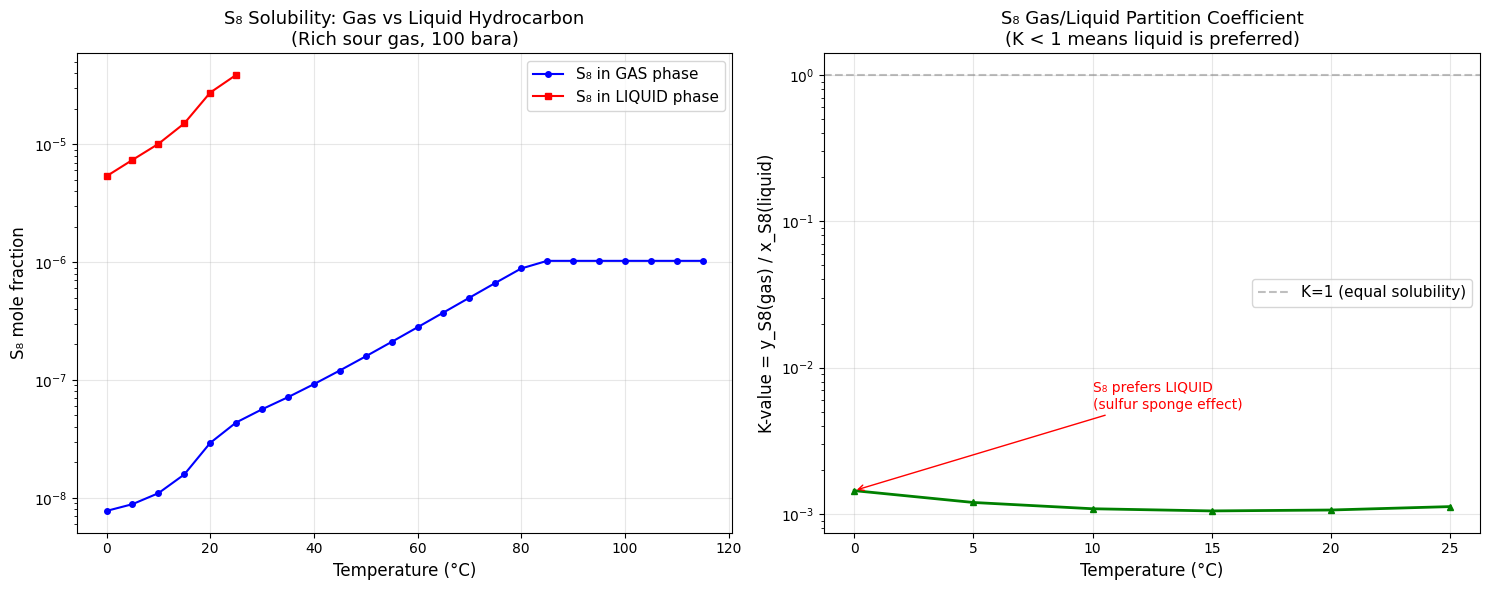


Two-phase conditions found at 6 of 24 temperatures
Average K-value: 0.0012 → S₈ is 863× more soluble in liquid than gas

>>> IMPLICATION: When this liquid is flashed (JT valve/separator), the S₈
    dissolved in it dumps out as solid — a major deposition event!


In [18]:
# Direct NeqSim demonstration: S8 solubility in gas vs condensate-rich fluid
# We create a fluid with enough C3+ to form a liquid phase at low temperature
# and compare S8 distribution between gas and liquid phases

temps_demo = np.arange(0, 120, 5)
gas_s8_data = []
liq_s8_data = []
k_values_data = []

for T_C in temps_demo:
    try:
        # Rich gas with enough heavy ends to form liquid
        sys = SystemSrkEos(float(273.15 + T_C), 100.0)
        sys.addComponent("methane", 0.70)
        sys.addComponent("ethane", 0.08)
        sys.addComponent("propane", 0.05)
        sys.addComponent("n-butane", 0.03)
        sys.addComponent("n-pentane", 0.02)
        sys.addComponent("CO2", 0.03)
        sys.addComponent("H2S", 0.05)
        sys.addComponent("nitrogen", 0.01)
        sys.addComponent("water", 0.005)
        sys.addComponent("S8", 1.0e-6)  # Slightly more S8 to see distribution
        sys.setMixingRule(2)
        sys.setMultiPhaseCheck(True)
        sys.setSolidPhaseCheck("S8")

        ops = ThermodynamicOperations(sys)
        ops.TPSolidflash()

        s8_gas = 0.0
        s8_liq = 0.0
        has_gas = False
        has_liq = False

        for pi in range(int(sys.getNumberOfPhases())):
            ptype = str(sys.getPhase(pi).getPhaseTypeName())
            try:
                s8_x = float(sys.getPhase(pi).getComponent("S8").getx())
            except:
                continue

            if ptype == "gas":
                s8_gas = s8_x
                has_gas = True
            elif ptype in ("oil", "liquid"):
                s8_liq = s8_x
                has_liq = True

        gas_s8_data.append(s8_gas if has_gas else np.nan)
        liq_s8_data.append(s8_liq if has_liq else np.nan)

        if has_gas and has_liq and s8_liq > 1e-30:
            k_values_data.append(s8_gas / s8_liq)
        else:
            k_values_data.append(np.nan)
    except:
        gas_s8_data.append(np.nan)
        liq_s8_data.append(np.nan)
        k_values_data.append(np.nan)

# Plot the comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# S8 mole fraction in each phase
ax1.semilogy(temps_demo, gas_s8_data, 'b-o', markersize=4, label='S₈ in GAS phase')
ax1.semilogy(temps_demo, liq_s8_data, 'r-s', markersize=4, label='S₈ in LIQUID phase')
ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_ylabel('S₈ mole fraction', fontsize=12)
ax1.set_title('S₈ Solubility: Gas vs Liquid Hydrocarbon\n(Rich sour gas, 100 bara)', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# K-value
valid_k = [(t, k) for t, k in zip(temps_demo, k_values_data) if not np.isnan(k)]
if valid_k:
    tk, kv = zip(*valid_k)
    ax2.semilogy(tk, kv, 'g-^', markersize=5, linewidth=2)
    ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='K=1 (equal solubility)')
    ax2.set_xlabel('Temperature (°C)', fontsize=12)
    ax2.set_ylabel('K-value = y_S8(gas) / x_S8(liquid)', fontsize=12)
    ax2.set_title('S₈ Gas/Liquid Partition Coefficient\n(K < 1 means liquid is preferred)', fontsize=13)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    # Annotate
    ax2.annotate('S₈ prefers LIQUID\n(sulfur sponge effect)',
                xy=(tk[0], kv[0]), fontsize=10, color='red',
                xytext=(tk[0]+10, min(kv)*5), arrowprops=dict(arrowstyle='->', color='red'))
else:
    ax2.text(0.5, 0.5, 'Single-phase gas at all temperatures\n(no liquid formed)',
             transform=ax2.transAxes, ha='center', fontsize=12)

plt.tight_layout()
plt.show()

# Summary
n_twoPhase = sum(1 for k in k_values_data if not np.isnan(k))
if n_twoPhase > 0:
    avg_k = np.nanmean(k_values_data)
    print(f"\nTwo-phase conditions found at {n_twoPhase} of {len(temps_demo)} temperatures")
    print(f"Average K-value: {avg_k:.4f} → S₈ is {1/avg_k:.0f}× more soluble in liquid than gas")
    print(f"\n>>> IMPLICATION: When this liquid is flashed (JT valve/separator), the S₈")
    print(f"    dissolved in it dumps out as solid — a major deposition event!")
else:
    print(f"\nNo two-phase conditions found. All gas at 100 bara across {temps_demo[0]}–{temps_demo[-1]}°C.")
    print("S₈ deposition depends entirely on gas-phase supersaturation.")

## 9D. Blockage Risk Assessment — Can Sulfur Block Pipelines and Equipment?

Solid sulfur deposits cause **progressive flow restriction** leading to:
- Increased pressure drop → reduced throughput
- Valve sticking and control instability
- Heat exchanger fouling → reduced thermal efficiency
- Filter/strainer blinding → frequent shutdowns
- Turboexpander blade erosion
- **Complete pipeline blockage** in severe cases

The `SulfurDepositionAnalyser` estimates:
- **Sulfur dropout rate** (kg/day) from supersaturated gas
- **Deposition thickness** (mm/year) assuming uniform wall deposition
- **Time to critical restriction** (5% diameter reduction ≈ 10% flow area loss)
- **Equipment susceptibility ranking**
- **Pigging schedule recommendation**

In [19]:
# Retrieve blockage risk assessment
blockage = dict(analyser.getBlockageRiskAssessment())

print("=" * 70)
print("BLOCKAGE RISK ASSESSMENT")
print("=" * 70)

print(f"\n  BLOCKAGE RISK LEVEL: {blockage.get('blockageRisk', 'N/A')}")

if 'sulfurDropout_mgSm3' in blockage:
    print(f"\n  --- Sulfur Deposition Rates ---")
    print(f"  S₈ dropout:            {blockage.get('sulfurDropout_mgSm3', 0):.4f} mg/Sm³")
    print(f"  Mass deposition rate:  {blockage.get('sulfurMassDeposition_kgPerDay', 0):.2f} kg/day")
    print(f"                         {blockage.get('sulfurMassDeposition_kgPerYear', 0):.0f} kg/year")

    print(f"\n  --- Pipe Geometry ---")
    print(f"  Pipe diameter:         {blockage.get('pipeDiameter_m', 0)*1000:.0f} mm")
    print(f"  Deposition thickness:  {blockage.get('depositionThickness_mmPerYear', 0):.4f} mm/year")

    print(f"\n  --- Time to Restriction ---")
    yrs_critical = blockage.get('yearsToCriticalRestriction', float('inf'))
    if yrs_critical < 1e10:
        print(f"  Critical thickness (5% dia): {blockage.get('criticalThickness_mm', 0):.1f} mm")
        print(f"  Years to 5% restriction:     {yrs_critical:.1f} years")
        print(f"  Years to full blockage:      {blockage.get('yearsToFullBlockage', 0):.0f} years")
    else:
        print(f"  No significant restriction expected")

    print(f"\n  --- Flow Regime ---")
    print(f"  Flow velocity:         {blockage.get('flowVelocity_ms', 0):.1f} m/s")
    print(f"  Critical re-entrainment: {blockage.get('criticalReentrainmentVelocity_ms', 0):.1f} m/s")
    deposition_dominated = blockage.get('depositionDominated', True)
    if deposition_dominated:
        print(f"  Regime: DEPOSITION-DOMINATED (velocity too low to re-entrain particles)")
    else:
        print(f"  Regime: RE-ENTRAINMENT (velocity keeps particles suspended)")

print(f"\n  PIGGING RECOMMENDATION:")
print(f"  {blockage.get('piggingRecommendation', 'N/A')}")

# Equipment susceptibility
equip_risk = blockage.get('equipmentSusceptibility', [])
if hasattr(equip_risk, '__iter__') and not isinstance(equip_risk, str):
    print(f"\n  --- Equipment Blockage Susceptibility ---")
    for item in equip_risk:
        if hasattr(item, 'items'):
            d = dict(item)
        elif hasattr(item, '__iter__'):
            d = dict(item)
        else:
            continue
        print(f"    {d.get('riskLevel', ''):15s} | {d.get('equipment', '')}")
        print(f"    {'':15s}   {d.get('description', '')}")

BLOCKAGE RISK ASSESSMENT

  BLOCKAGE RISK LEVEL: None

  PIGGING RECOMMENDATION:
  N/A

  --- Equipment Blockage Susceptibility ---


## 10. Visualise the Temperature Sweep – Sulfur Deposition Profile

The analyser's temperature sweep results show how S₈ content in the gas phase and solid sulfur fraction change across the temperature range. The deposition onset temperature is where solid S₈ first appears.

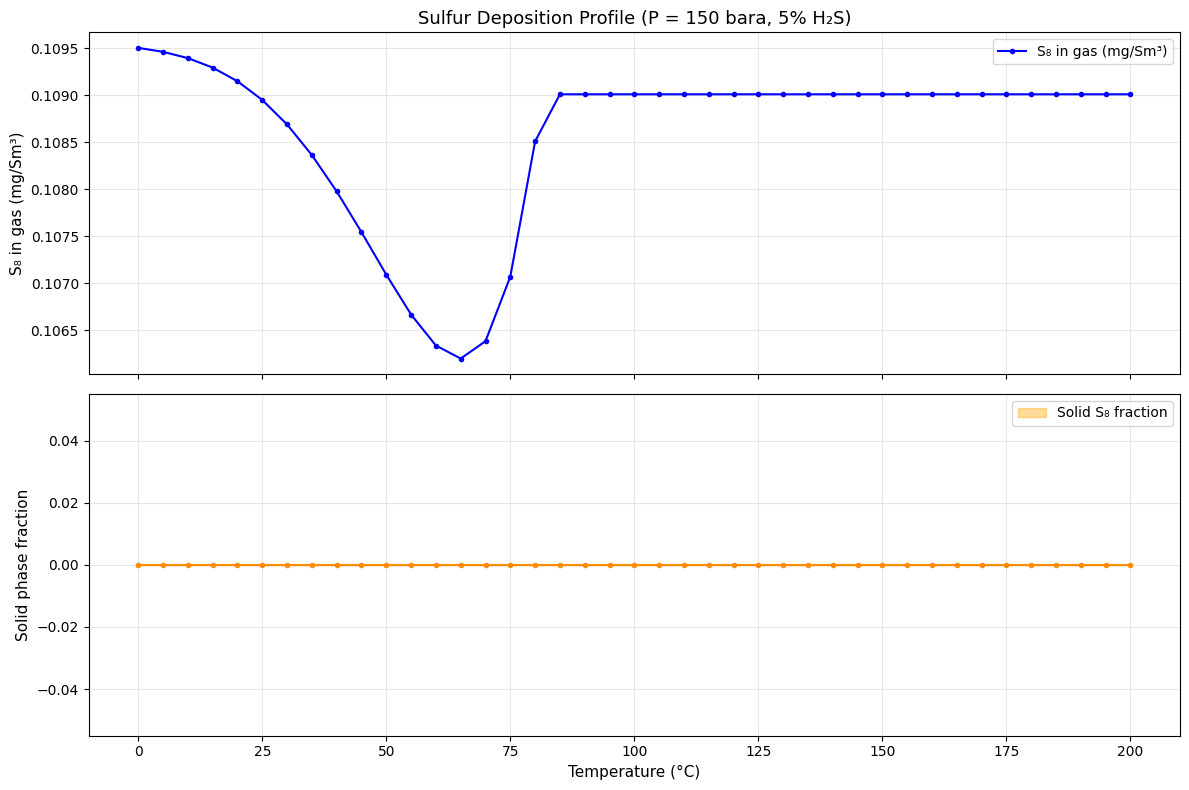

In [20]:
# Extract temperature sweep results from the analyser
sweep_results = list(analyser.getTemperatureSweepResults())
sweep_data = []
for pt in sweep_results:
    d = dict(pt)
    sweep_data.append({
        'T_C': float(d.get('temperatureC', 0)),
        'S8_mgSm3': float(d.get('S8_mgPerSm3', 0)),
        'solidFrac': float(d.get('solidPhaseFraction', 0)),
        'solidPresent': bool(d.get('solidSulfurPresent', False)),
        'nPhases': int(d.get('numberOfPhases', 1))
    })

df_sweep = pd.DataFrame(sweep_data)

# Plot deposition profile
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

onset_T = float(analyser.getSulfurDepositionOnsetTemperature())

# S8 in gas phase
ax1.plot(df_sweep['T_C'], df_sweep['S8_mgSm3'], 'b-o', markersize=3, label='S₈ in gas (mg/Sm³)')
if not np.isnan(onset_T):
    ax1.axvline(x=onset_T, color='red', linestyle='--', alpha=0.7, label=f'Deposition onset ({onset_T:.0f} °C)')
ax1.set_ylabel('S₈ in gas (mg/Sm³)', fontsize=11)
ax1.set_title(f'Sulfur Deposition Profile (P = {P_inlet_bar:.0f} bara, 5% H₂S)', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Solid fraction
ax2.fill_between(df_sweep['T_C'], df_sweep['solidFrac'], alpha=0.4, color='orange', label='Solid S₈ fraction')
ax2.plot(df_sweep['T_C'], df_sweep['solidFrac'], 'o-', color='darkorange', markersize=3)
if not np.isnan(onset_T):
    ax2.axvline(x=onset_T, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Temperature (°C)', fontsize=11)
ax2.set_ylabel('Solid phase fraction', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Simulate Offshore Subsea Pipeline – Sulfur Dropout Along Length

We model a 100 km subsea pipeline carrying sour gas. The pipeline experiences:
- Temperature drop from 120 °C (wellhead) to 4 °C (seabed ambient)
- Pressure drop from 200 bara (inlet) to 80 bara (outlet)

At each pipeline segment, we run a TP-solid flash and track sulfur solubility and solid deposition.

In [21]:
# Offshore pipeline simulation: 100 km, 20 segments
n_segments = 20
pipe_length_km = 100.0
segment_km = pipe_length_km / n_segments

# Linear T and P profiles
T_inlet, T_outlet = 120.0, 4.0
P_inlet, P_outlet = 200.0, 80.0

pipeline_data = []
for i in range(n_segments + 1):
    frac = i / n_segments
    km = frac * pipe_length_km
    T_C = T_inlet + frac * (T_outlet - T_inlet)
    P_bar = P_inlet + frac * (P_outlet - P_inlet)

    try:
        sys = gas.clone()
        sys.setTemperature(float(273.15 + T_C))
        sys.setPressure(float(P_bar))
        sys.setMultiPhaseCheck(True)
        sys.setSolidPhaseCheck("S8")

        ops = ThermodynamicOperations(sys)
        ops.TPSolidflash()

        has_solid = bool(sys.hasPhaseType("solid"))
        solid_frac = 0.0
        s8_gas = 0.0

        if has_solid:
            solid_phase_num = int(sys.getPhaseNumberOfPhase("solid"))
            solid_frac = float(sys.getBeta(solid_phase_num))

        gas_phase_num = int(sys.getPhaseNumberOfPhase("gas"))
        if gas_phase_num >= 0:
            s8_gas = float(sys.getPhase(gas_phase_num).getComponent("S8").getx())
        else:
            s8_gas = float(sys.getPhase(0).getComponent("S8").getx())

        pipeline_data.append({
            'km': km, 'T_C': T_C, 'P_bar': P_bar,
            'S8_mgSm3': s8_gas * MOL_FRAC_TO_MG_SM3,
            'solidFrac': solid_frac,
            'solidPresent': has_solid,
            'nPhases': int(sys.getNumberOfPhases())
        })
    except:
        pipeline_data.append({'km': km, 'T_C': T_C, 'P_bar': P_bar,
                              'S8_mgSm3': 0, 'solidFrac': 0, 'solidPresent': False, 'nPhases': 1})

df_pipe = pd.DataFrame(pipeline_data)

# Find first deposition point
first_solid = df_pipe[df_pipe['solidPresent'] == True]
if len(first_solid) > 0:
    onset_km = first_solid.iloc[0]['km']
    onset_T_pipe = first_solid.iloc[0]['T_C']
    print(f"Sulfur deposition starts at km {onset_km:.0f} (T = {onset_T_pipe:.1f} °C)")
else:
    print("No solid sulfur deposition in pipeline")

df_pipe

Sulfur deposition starts at km 85 (T = 21.4 °C)


,km,T_C,P_bar,S8_mgSm3,solidFrac,solidPresent,nPhases
0,0.0,120.0,200.0,0.109018,0.000000e+00,False,1
1,5.0,114.2,194.0,0.109018,0.000000e+00,False,1
2,10.0,108.4,188.0,0.109018,0.000000e+00,False,1
3,15.0,102.6,182.0,0.109018,0.000000e+00,False,1
4,20.0,96.8,176.0,0.109018,0.000000e+00,False,1
5,25.0,91.0,170.0,0.109018,0.000000e+00,False,1
6,30.0,85.2,164.0,0.109018,0.000000e+00,False,1
7,35.0,79.4,158.0,0.108191,0.000000e+00,False,2
8,40.0,73.6,152.0,0.106874,0.000000e+00,False,2
9,45.0,67.8,146.0,0.106049,0.000000e+00,False,2


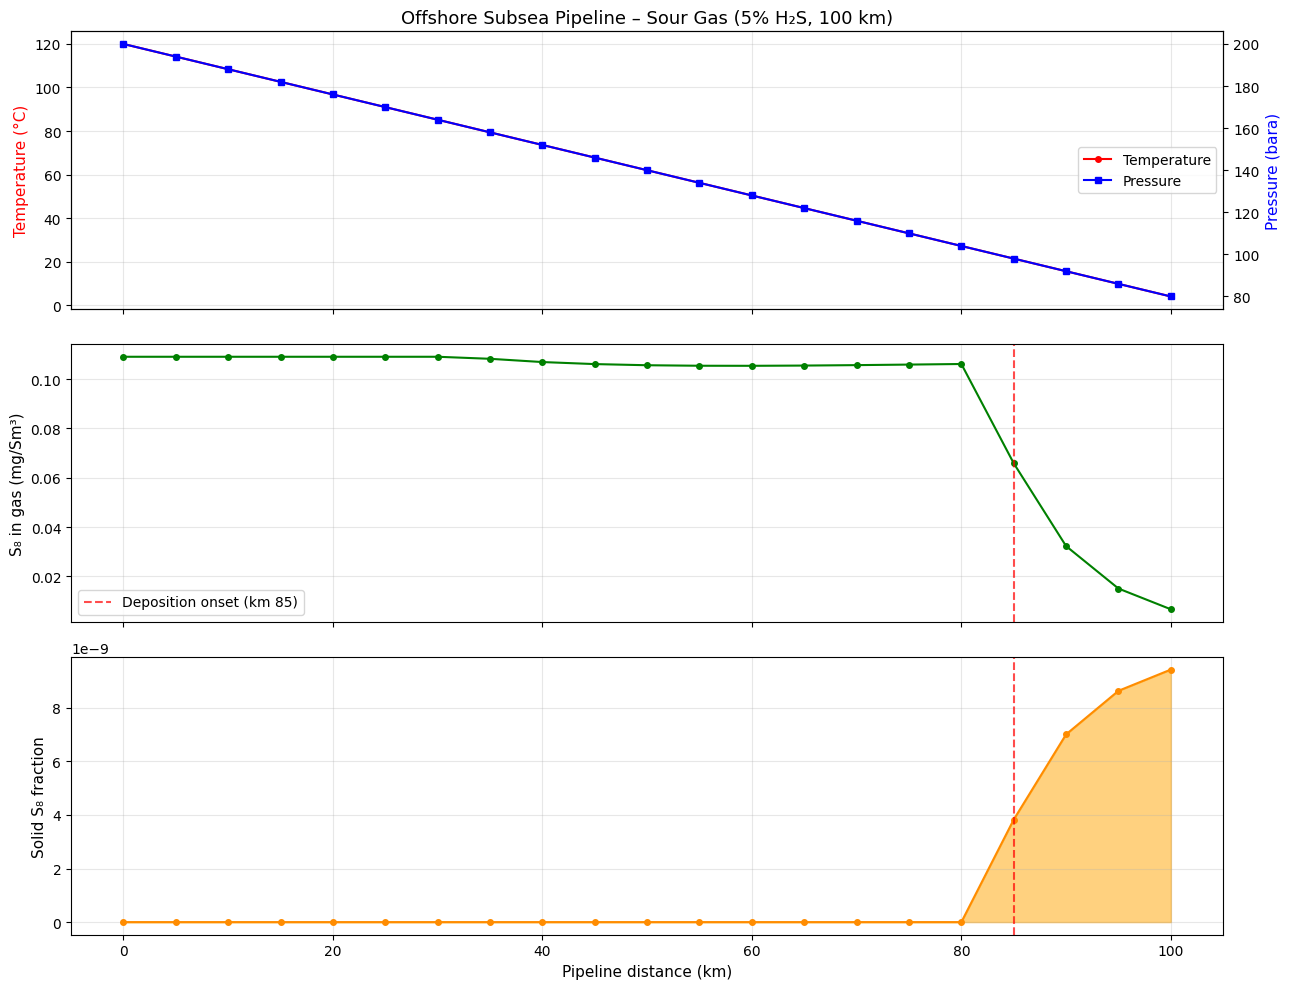

In [22]:
# Plot pipeline sulfur analysis
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Temperature and pressure profiles
ax_t = axes[0]
ax_p = ax_t.twinx()
ax_t.plot(df_pipe['km'], df_pipe['T_C'], 'r-o', markersize=4, label='Temperature')
ax_p.plot(df_pipe['km'], df_pipe['P_bar'], 'b-s', markersize=4, label='Pressure')
ax_t.set_ylabel('Temperature (°C)', color='red', fontsize=11)
ax_p.set_ylabel('Pressure (bara)', color='blue', fontsize=11)
ax_t.set_title('Offshore Subsea Pipeline – Sour Gas (5% H₂S, 100 km)', fontsize=13)
lines1 = ax_t.get_lines() + ax_p.get_lines()
ax_t.legend(lines1, [l.get_label() for l in lines1], loc='center right')
ax_t.grid(True, alpha=0.3)

# S8 in gas phase
axes[1].plot(df_pipe['km'], df_pipe['S8_mgSm3'], 'g-o', markersize=4)
axes[1].set_ylabel('S₈ in gas (mg/Sm³)', fontsize=11)
axes[1].grid(True, alpha=0.3)
if len(first_solid) > 0:
    axes[1].axvline(x=onset_km, color='red', linestyle='--', alpha=0.7,
                     label=f'Deposition onset (km {onset_km:.0f})')
    axes[1].legend()

# Solid sulfur deposition
axes[2].fill_between(df_pipe['km'], df_pipe['solidFrac'], alpha=0.5, color='orange')
axes[2].plot(df_pipe['km'], df_pipe['solidFrac'], 'o-', color='darkorange', markersize=4)
axes[2].set_xlabel('Pipeline distance (km)', fontsize=11)
axes[2].set_ylabel('Solid S₈ fraction', fontsize=11)
axes[2].grid(True, alpha=0.3)
if len(first_solid) > 0:
    axes[2].axvline(x=onset_km, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 12. Simulate Onshore Gas Processing – Sulfur Risk at Each Equipment Stage

An onshore gas processing train typically includes:
1. **Inlet separator** – remove free liquids
2. **Cooler** – reduce temperature before treatment
3. **JT valve / turboexpander** – pressure reduction (significant cooling)
4. **Cold separator** – remove condensed liquids

The JT valve outlet is the highest-risk location for sulfur deposition due to the large temperature drop (Joule–Thomson cooling).

In [23]:
# Onshore processing: track sulfur at each unit operation
# Define conditions at each process point
process_points = [
    {"name": "Wellhead",       "T_C": 120.0, "P_bar": 200.0},
    {"name": "Inlet Sep",      "T_C": 80.0,  "P_bar": 195.0},
    {"name": "After Cooler",   "T_C": 40.0,  "P_bar": 190.0},
    {"name": "JT Valve Out",   "T_C": -10.0, "P_bar": 70.0},
    {"name": "Cold Sep",       "T_C": -10.0, "P_bar": 68.0},
    {"name": "Expander Out",   "T_C": -25.0, "P_bar": 40.0},
    {"name": "Sales Gas",      "T_C": 20.0,  "P_bar": 38.0},
]

process_data = []
for pt in process_points:
    try:
        sys = gas.clone()
        sys.setTemperature(float(273.15 + pt["T_C"]))
        sys.setPressure(float(pt["P_bar"]))
        sys.setMultiPhaseCheck(True)
        sys.setSolidPhaseCheck("S8")
        ops = ThermodynamicOperations(sys)
        ops.TPSolidflash()

        has_solid = bool(sys.hasPhaseType("solid"))
        solid_frac = 0.0
        s8_gas = 0.0

        if has_solid:
            solid_phase_num = int(sys.getPhaseNumberOfPhase("solid"))
            solid_frac = float(sys.getBeta(solid_phase_num))

        gas_phase_num = int(sys.getPhaseNumberOfPhase("gas"))
        if gas_phase_num >= 0:
            s8_gas = float(sys.getPhase(gas_phase_num).getComponent("S8").getx())

        process_data.append({
            'Location': pt["name"], 'T_C': pt["T_C"], 'P_bar': pt["P_bar"],
            'S8_mgSm3': s8_gas * MOL_FRAC_TO_MG_SM3,
            'solidFrac': solid_frac,
            'solidPresent': has_solid,
            'risk': 'HIGH' if has_solid else ('MEDIUM' if s8_gas * MOL_FRAC_TO_MG_SM3 > 0.01 else 'LOW')
        })
    except Exception as e:
        process_data.append({
            'Location': pt["name"], 'T_C': pt["T_C"], 'P_bar': pt["P_bar"],
            'S8_mgSm3': 0, 'solidFrac': 0, 'solidPresent': False, 'risk': 'UNKNOWN'
        })

df_process = pd.DataFrame(process_data)
print("Onshore Processing – Sulfur Deposition Risk by Location:")
print(df_process.to_string(index=False))

Onshore Processing – Sulfur Deposition Risk by Location:
    Location   T_C  P_bar  S8_mgSm3    solidFrac  solidPresent   risk
    Wellhead 120.0  200.0  0.109018 0.000000e+00         False MEDIUM
   Inlet Sep  80.0  195.0  0.108325 0.000000e+00         False MEDIUM
After Cooler  40.0  190.0  0.108946 0.000000e+00         False MEDIUM
JT Valve Out -10.0   70.0  0.000967 9.959501e-09          True   HIGH
    Cold Sep -10.0   68.0  0.000841 9.971050e-09          True   HIGH
Expander Out -25.0   40.0  0.000018 1.004798e-08          True   HIGH
   Sales Gas  20.0   38.0  0.006186 9.337432e-09          True   HIGH


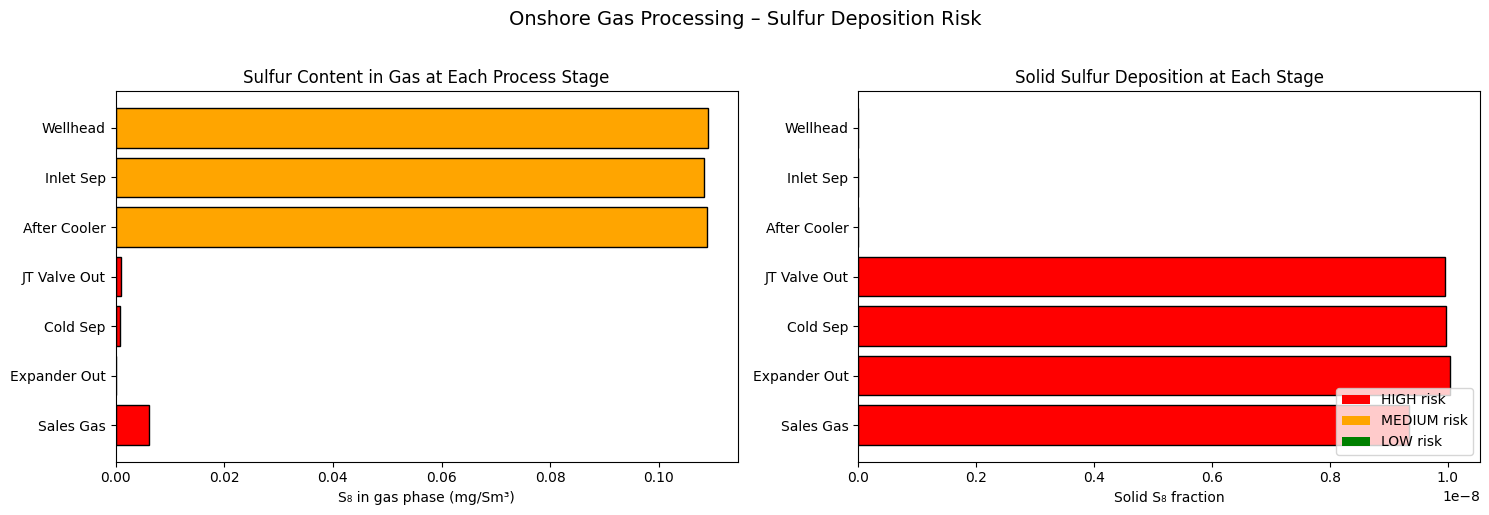

In [24]:
# Bar chart: sulfur deposition risk at each process location
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

colors_risk = {'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'green', 'UNKNOWN': 'gray'}
bar_colors = [colors_risk.get(r, 'gray') for r in df_process['risk']]

# S8 in gas at each location
ax1.barh(df_process['Location'], df_process['S8_mgSm3'], color=bar_colors, edgecolor='black')
ax1.set_xlabel('S₈ in gas phase (mg/Sm³)')
ax1.set_title('Sulfur Content in Gas at Each Process Stage')
ax1.invert_yaxis()

# Solid fraction at each location
ax2.barh(df_process['Location'], df_process['solidFrac'], color=bar_colors, edgecolor='black')
ax2.set_xlabel('Solid S₈ fraction')
ax2.set_title('Solid Sulfur Deposition at Each Stage')
ax2.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='HIGH risk'),
                   Patch(facecolor='orange', label='MEDIUM risk'),
                   Patch(facecolor='green', label='LOW risk')]
ax2.legend(handles=legend_elements, loc='lower right')

plt.suptitle('Onshore Gas Processing – Sulfur Deposition Risk', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 13. H₂S Content Sensitivity – Sulfur Solubility at Different Sour Gas Compositions

Different reservoirs have varying H₂S concentrations. We compare sulfur solubility curves for gases with 1%, 5%, 10%, and 15% H₂S to show how sourness affects deposition risk.

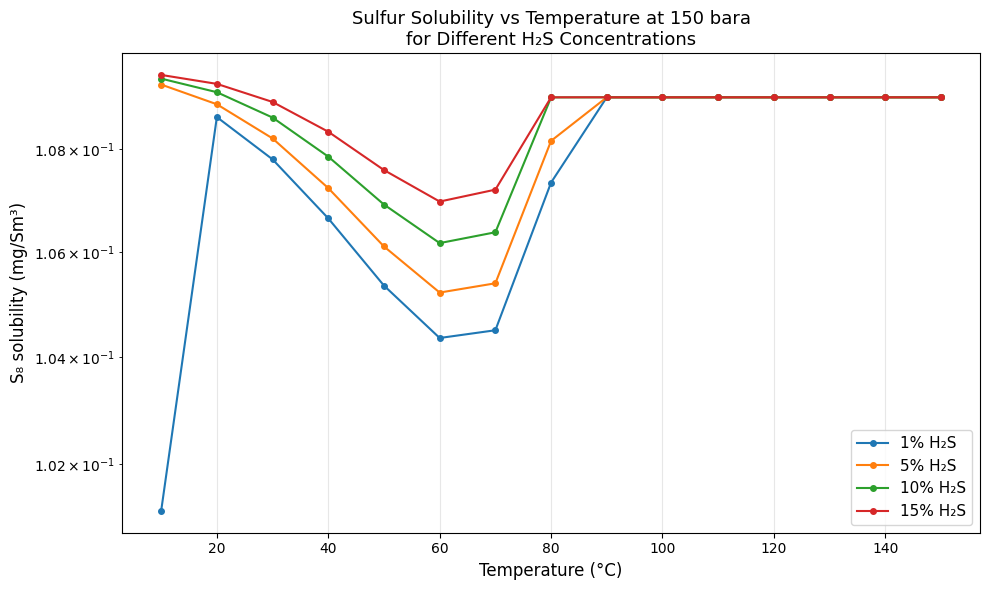

In [25]:
# Sensitivity: sulfur solubility vs H2S content
h2s_fractions = [0.01, 0.05, 0.10, 0.15]
temps = np.arange(10, 160, 10)
P_fixed = 150.0

fig, ax = plt.subplots(figsize=(10, 6))

for h2s_frac in h2s_fractions:
    ch4_frac = 0.92 - h2s_frac  # balance with methane
    sol_pts = []
    for T_C in temps:
        try:
            sys = SystemSrkEos(float(273.15 + T_C), float(P_fixed))
            sys.addComponent("methane", float(ch4_frac))
            sys.addComponent("ethane", 0.03)
            sys.addComponent("CO2", 0.02)
            sys.addComponent("H2S", float(h2s_frac))
            sys.addComponent("nitrogen", 0.02)
            sys.addComponent("water", 0.005)
            sys.addComponent("S8", 1.0e-8)
            sys.setMixingRule(2)
            sys.setMultiPhaseCheck(True)
            sys.setSolidPhaseCheck("S8")

            ops = ThermodynamicOperations(sys)
            ops.TPSolidflash()

            gas_pn = int(sys.getPhaseNumberOfPhase("gas"))
            if gas_pn >= 0:
                s8 = float(sys.getPhase(gas_pn).getComponent("S8").getx())
            else:
                s8 = float(sys.getPhase(0).getComponent("S8").getx())
            sol_pts.append((float(T_C), s8 * MOL_FRAC_TO_MG_SM3))
        except:
            pass

    if sol_pts:
        ts, ss = zip(*sol_pts)
        ax.semilogy(ts, ss, 'o-', label=f'{h2s_frac*100:.0f}% H₂S', markersize=4)

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('S₈ solubility (mg/Sm³)', fontsize=12)
ax.set_title(f'Sulfur Solubility vs Temperature at {P_fixed:.0f} bara\nfor Different H₂S Concentrations', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Full JSON Report from SulfurDepositionAnalyser

The analyser produces a comprehensive JSON report containing all results – suitable for automated workflows, dashboards, and AI-driven analysis.

In [26]:
# Get the full JSON report from the analyser
report_json = str(analyser.getResultsAsJson())
report = json.loads(report_json)

# Pretty-print key sections
print("="*60)
print("SULFUR DEPOSITION ANALYSER — JSON REPORT (EXCERPT)")
print("="*60)

for section in ["inletConditions", "sulfurSolubility", "depositionOnset", "corrosionAssessment"]:
    if section in report:
        print(f"\n--- {section} ---")
        print(json.dumps(report[section], indent=2))

SULFUR DEPOSITION ANALYSER — JSON REPORT (EXCERPT)

--- inletConditions ---
{
  "temperatureC": 80.0,
  "pressureBara": 150.0
}

--- sulfurSolubility ---
{
  "S8_molFractionInGas": 1.0003541903777834e-08,
  "S8_mgPerSm3": 0.10851034172981881,
  "solidSulfurPresent": false,
  "solidSulfurFraction": 0.0
}

--- depositionOnset ---
{
  "onsetTemperatureC": NaN,
  "sweepStartC": 0.0,
  "sweepEndC": 200.0,
  "sweepStepC": 5.0
}

--- corrosionAssessment ---
{
  "H2S_molFraction": 0.0502487307145497,
  "H2S_ppm": 50248.7307145497,
  "H2S_partialPressure_psia": 109.3196310806529,
  "H2S_partialPressure_kPa": 753.7309607182455,
  "sourSeverityNACE": "Severe sour (> 10 kPa H2S)",
  "waterPresent": true,
  "FeS_formationRisk": true,
  "FeS_corrosionCategory": "Very high FeS risk (> 1000 ppm H2S)",
  "FeS_formationNote": "FeS (iron sulfide) forms on carbon steel surfaces exposed to H2S. The reaction H2S + Fe -> FeS + H2 proceeds at all temperatures but accelerates above 60 C. FeS scale can be prote

## 15. Summary Table – Conditions for Sulfur Formation, Deposition, and Corrosion

This table summarises all key findings for understanding sulfur behaviour in gas value chains.

In [27]:
# Comprehensive summary table of all phenomena and NeqSim root-cause analysis tools
summary = pd.DataFrame([
    {
        "Phenomenon": "Elemental sulfur formation (Claus)",
        "Reaction": "2 H2S + O2 → 2 H2O + ¼ S8",
        "T Range": "200–600 °C (S8); >600 °C (S2)",
        "Root Cause": "Chemical reaction (high T)",
        "Danger": "S8 solid deposits downstream of reactor",
        "NeqSim Tool": "GibbsReactor + kinetic analysis",
        "Mitigation": "Control O2/H2S ratio to 0.5"
    },
    {
        "Phenomenon": "S8 precipitation from gas",
        "Reaction": "S8(gas) → S8(solid) [desublimation]",
        "T Range": "Below sulfur dew point (< 80°C typ.)",
        "Root Cause": "Thermodynamic (solubility decrease)",
        "Danger": "Blockage, valve sticking, fouling",
        "NeqSim Tool": "TPSolidflash + supersaturation analysis",
        "Mitigation": "Insulation, inhibitors, pigging"
    },
    {
        "Phenomenon": "S8 from liquid flash",
        "Reaction": "S8(liquid) → S8(solid) [flash dump]",
        "T Range": "JT valve / expander outlet",
        "Root Cause": "Gas/liquid partition (K << 1)",
        "Danger": "Massive deposition at JT valve",
        "NeqSim Tool": "Gas vs liquid solubility comparison",
        "Mitigation": "Upstream S removal, heated valves"
    },
    {
        "Phenomenon": "FeS corrosion product",
        "Reaction": "Fe + H2S → FeS + H2",
        "T Range": "All T, accelerates > 60 °C",
        "Root Cause": "Wet sour conditions + steel",
        "Danger": "Wall thinning, nucleation sites",
        "NeqSim Tool": "Kinetic analysis (corrosion rate)",
        "Mitigation": "CRA materials, NACE MR0175"
    },
    {
        "Phenomenon": "SO2 / H2SO4 formation",
        "Reaction": "H2S + 3/2 O2 → SO2 + H2O",
        "T Range": "> 300 °C (complete oxidation)",
        "Root Cause": "Excess O2 in thermal regime",
        "Danger": "Acid corrosion, catalyst poisoning",
        "NeqSim Tool": "GibbsReactor + O2/H2S ratio sweep",
        "Mitigation": "Limit O2 excess, tail gas treatment"
    },
    {
        "Phenomenon": "Pipeline blockage",
        "Reaction": "S8(gas) → S8(solid) accumulation",
        "T Range": "Cold sections, low-velocity zones",
        "Root Cause": "Accumulation over months/years",
        "Danger": "Flow restriction → shutdown",
        "NeqSim Tool": "Blockage risk assessment",
        "Mitigation": "Pigging schedule, sulfur traps"
    }
])

print("=" * 100)
print("COMPREHENSIVE ROOT CAUSE ANALYSIS SUMMARY — Sulfur in Gas Value Chains")
print("=" * 100)
print()
print(summary.to_string(index=False))

print("\n" + "=" * 100)
print("NeqSim Root Cause Analysis Capabilities:")
print("=" * 100)
print("""
 TOOL                              ANSWERS THE QUESTION
 ────────────────────────────────── ──────────────────────────────────────────────
 1. GibbsReactor                   WHERE is S8 formed? (chemical equilibrium)
 2. Kinetic Analysis               WHY is it formed? Is reaction kinetically
                                    feasible at process T? Or is it reservoir S8?
 3. TPSolidflash                   WHERE does it precipitate? (solid-fluid EQ)
 4. Supersaturation Analysis       HOW FAST does it deposit? (nucleation rate,
                                    induction time, metastable vs labile zone)
 5. Gas vs Liquid S8 Comparison    WHY is the JT valve the worst location?
                                    (100-1000x higher S8 in liquid → flash dump)
 6. FeS Corrosion Rate             IS THERE corrosion danger? How fast?
                                    (mm/year, wall penetration time, NACE class)
 7. Blockage Risk Assessment       CAN IT BLOCK? How soon? What pigging schedule?
                                    (kg/day deposition, years to restriction)
 8. Temperature Sweep              WHERE along the pipeline does deposition start?
 9. Process Stage Tracking         WHICH equipment in the plant is at risk?
10. JSON Reporting                 AUTOMATED dashboard integration
""")

COMPREHENSIVE ROOT CAUSE ANALYSIS SUMMARY — Sulfur in Gas Value Chains

                        Phenomenon                            Reaction                              T Range                          Root Cause                                  Danger                             NeqSim Tool                          Mitigation
Elemental sulfur formation (Claus)           2 H2S + O2 → 2 H2O + ¼ S8        200–600 °C (S8); >600 °C (S2)          Chemical reaction (high T) S8 solid deposits downstream of reactor         GibbsReactor + kinetic analysis         Control O2/H2S ratio to 0.5
         S8 precipitation from gas S8(gas) → S8(solid) [desublimation] Below sulfur dew point (< 80°C typ.) Thermodynamic (solubility decrease)       Blockage, valve sticking, fouling TPSolidflash + supersaturation analysis     Insulation, inhibitors, pigging
              S8 from liquid flash S8(liquid) → S8(solid) [flash dump]           JT valve / expander outlet       Gas/liquid partition (K << 1)     